# Exploratory Data Analysis: Drug Consumption Dataset

**Course:** Data Science — Summer Semester 2026  
**Dataset:** Drug Consumption (UCI Machine Learning Repository)  
**Author:** *Daniel Marquino Pérez*

---

## 1. Dataset Description and Origin

The *Drug Consumption* dataset was collected via an online survey and made publicly available through the UCI Machine Learning Repository. The study aimed to investigate the relationship between personality traits and drug consumption behaviour.

The dataset contains **1,885 respondents** and **31 features**, organised into three groups:

| Feature Group | Variables | Measurement Scale |
|---|---|---|
| Demographic | Age, Gender, Education, Country, Ethnicity | Nominal / Ordinal |
| Personality scores | Nscore, Escore, Oscore, AScore, Cscore, Impulsive, SS | Quantitative continuous (standardised z-scores) |
| Drug consumption | 18 substances (Alcohol, Cannabis, Nicotine, ...) | Ordinal (CL0–CL6) |

**Drug consumption scale:**  
*CL0* = Never used | *CL1* = Over a decade ago | *CL2* = Last decade | *CL3* = Last year | *CL4* = Last month | *CL5* = Last week | *CL6* = Last day

**Personality scores:**  
*Nscore* = Neuroticism | *Escore* = Extraversion | *Oscore* = Openness | *AScore* = Agreeableness | *Cscore* = Conscientiousness | *Impulsive* = Impulsiveness | *SS* = Sensation Seeking

> **Note on Semer:** `Semer` is a fictional drug included as a validity check. Respondents who report using it may be answering carelessly and are flagged in Section 7.

---
## 2. Research Questions

Based on the structure of the dataset, the following analytical questions can be explored:

1. **Are certain personality traits associated with higher levels of drug consumption?**
2. **Are there demographic patterns in drug consumption? for example, do younger respondents report more frequent cannabis use?**
3. **Is the Semer (*fictitious drug*) report rate low enough to confirm dataset validity?**
4. **Which substances show the highest usage frequency, and how clearly do legal and illegal substances differ?**

---
## 3. Setup: Import Packages

In [ ]:
# Import packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt   # Graphics package

# Set path - please adjust
os.chdir(r'C:\Users\danie\Documents\uni\s2026.1\data science\project\explorative-data-analysis')   # copy path from File Explorer; r prevents backslash from being treated as escape character

# Read data
myData = pd.read_csv('Drug_Consumption.csv')

# Remove the ID column - it is a row identifier with no analytical value
myData = myData.drop(columns=['ID'])

print('Dataset loaded.')
myData

---
## 4. Initial Inspection

To get some initial information, the methods `info` and `size` are used.

In [ ]:
# Overview of columns, data types, and non-null counts
myData.info()

In [ ]:
# Table size
size = myData.shape
print('Number of rows:   ', size[0])
print('Number of columns:', size[1])

---
## 5. Missing Values

Missing values can occur as MCAR (Missing Completely At Random), MAR (Missing At Random), or NMAR (Not Missing At Random). Before any analysis it is necessary to check how many values are missing and to consider why.

In [ ]:
# Count missing values per column
missing_values = myData.isnull().sum()

print('Missing values per column:')
print(missing_values)

print('\nTotal missing values: %d' % missing_values.sum())

The dataset contains **no missing values**. This is explained by the survey design: all questions were mandatory in order to submit the form. No imputation is required, which eliminates the risk of introducing bias.

---
## 6. Feature Classification by Measurement Scale

Before applying any statistical method, each variable must be classified by its measurement scale. The scale determines which operators, charts, and statistics are valid for each feature.

In [ ]:
# Define column groups by measurement scale
demographic_nominal = ['Gender', 'Country', 'Ethnicity']                                        # nominal: values are names, no natural order
demographic_ordinal = ['Age', 'Education']                                                      # ordinal: values have a natural order
personality_scores  = ['Nscore', 'Escore', 'Oscore', 'AScore', 'Cscore', 'Impulsive', 'SS']     # quantitative continuous (ratio scale)
drug_columns        = ['Alcohol','Amphet','Amyl','Benzos','Caff','Cannabis','Choc',
                       'Coke','Crack','Ecstasy','Heroin','Ketamine','Legalh',
                       'LSD','Meth','Mushrooms','Nicotine','Semer','VSA']                       # ordinal: CL0 (never) to CL6 (last day)

print('Nominal (demographic)   :', demographic_nominal)
print('Ordinal (demographic)   :', demographic_ordinal)
print('Ratio   (personality)   :', personality_scores)
print('Ordinal (drug use, n=%d):' % len(drug_columns), drug_columns)

---
## 7. Semer Validity Check

Semer is a **fictitious drug** included in the survey to detect careless respondents. Any participant claiming to have used it is flagged as potentially unreliable.

In [ ]:
# Frequency table for Semer ordered by CL-level
tab_semer = myData['Semer'].value_counts()
ordered_semer = tab_semer.index.sort_values()
tab_semer = tab_semer[ordered_semer]

print(tab_semer)

semer_users = (myData['Semer'] != 'CL0').sum()
semer_percentage = 100 * semer_users / len(myData)
print('\nRespondents reporting Semer use: %d (%.1f%% of total)' % (semer_users, semer_percentage))

Only **8 respondents (0.4%)** claim to have used the fictional substance. This very low rate confirms that the majority of participants answered the survey conscientiously, supporting the reliability of the dataset.

---


## 8. Graphical Representation

The choice of chart type depends directly from the measurement scale of the feature. Pie charts and bar charts are appropriate for **nominal and ordinal** features; histograms are used for **continuous** features; boxplots visualise the distribution of a continuous feature and allow comparison across groups.


### 8.1 Frequency Table and Bar Chart — Gender

As gender is a **nominal** feature, a bar chart is the appropriate visualisation.

In [ ]:
# Frequency table for Gender
tab_gender = myData['Gender'].value_counts()

print(tab_gender)
print('The most common gender in the sample is %s.' % tab_gender.index[0])

# Bar chart for gender distribution
fig, ax = plt.subplots()

bars = ax.bar(tab_gender.index, tab_gender.values)    # column chart for nominal feature

colormap = plt.cm.viridis                              # use a colormap for visual distinction
colors = ['lightblue', 'lightcoral']                          # two distinct shades from the map
for bar, color in zip(bars, colors):
    bar.set_color(color)

for bar in bars:                                       # add absolute frequency labels above each bar
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom')

ax.set_title('Gender distribution of survey respondents')
ax.set_xlabel('Gender')
ax.set_ylabel('Absolute frequency')

### 8.2 Bar Chart — Age Group

Age is an **ordinal** feature with a clear natural order, the bars are arranged from youngest to oldest to respect this ordering.

In [ ]:
tab_age = myData['Age'].value_counts()

age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']        # define meaningful order for the ordinal feature
tab_age = tab_age.reindex(age_order)                                    # reorder the frequency table accordingly

print(tab_age)
print('\nThe most frequent age group is %s.' % tab_age.idxmax())

# Bar chart for age distribution
fig, ax = plt.subplots()

bars = ax.bar(tab_age.index, tab_age.values)

colormap = plt.cm.viridis
colors = ['lightcoral', 'orange', 'yellow', 'lightgreen', 'lightblue', 'lightpink']  # distinct shades for each age group
for bar, color in zip(bars, colors):
    bar.set_color(color)

ax.set_title('Age distribution of survey respondents')
ax.set_xlabel('Age group')
ax.set_ylabel('Absolute frequency')
plt.xticks(rotation=20)

### 8.3 Horizontal Bar Chart — Education Level

Education is ordinal with long label names, so a **horizontal bar chart** improves readability.

In [ ]:
tab_edu = myData['Education'].value_counts()

ax = tab_edu.plot(kind='barh', figsize=(9, 5), color='navy')    # pandas method for horizontal bar chart
plt.xlabel('Absolute frequency')
plt.ylabel('Education level')
plt.title('Education distribution of survey respondents')
plt.tight_layout()

### 8.4 Pie Chart — Country of Residence

A pie chart is appropriate for **nominal** features when the number of categories is small and the focus is on proportions.

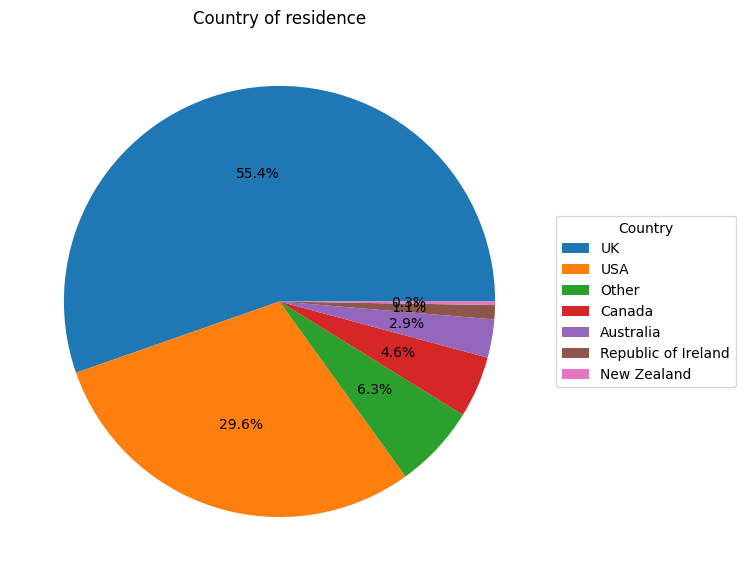

In [13]:
tab_country = myData['Country'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    tab_country,
    autopct='%1.1f%%'        # display relative frequency per segment to one decimal place
)

ax.set_title('Country of residence')
labels = tab_country.index

ax.legend(wedges, labels,
          title='Country',
          loc='center left',
          bbox_to_anchor=(1, 0, 0.5, 1))    # legend placed outside the chart area

### 8.5 Histograms — Personality Scores

Personality scores are **quantitative continuous** features on a ratio scale. Histograms are the correct representation.

Text(0.5, 1.0, 'Histogram of Neuroticism scores')

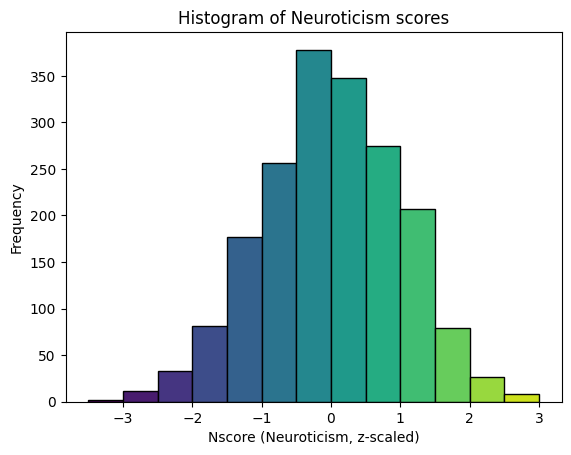

In [14]:
# Histogram for Nscore (Neuroticism) with manually chosen bin width
fig, ax = plt.subplots()

myBins = np.arange(-3.5, 3.5, 0.5)     # bins from -3.5 to 3.5 in steps of 0.5; covers the full z-score range

heights, bins, patches = ax.hist(myData['Nscore'], bins=myBins, edgecolor='black')

for i in range(len(patches)):            # apply colormap across the bars
    patches[i].set_facecolor(plt.cm.viridis(i / len(patches)))

ax.set_xlabel('Nscore (Neuroticism, z-scaled)')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Neuroticism scores')

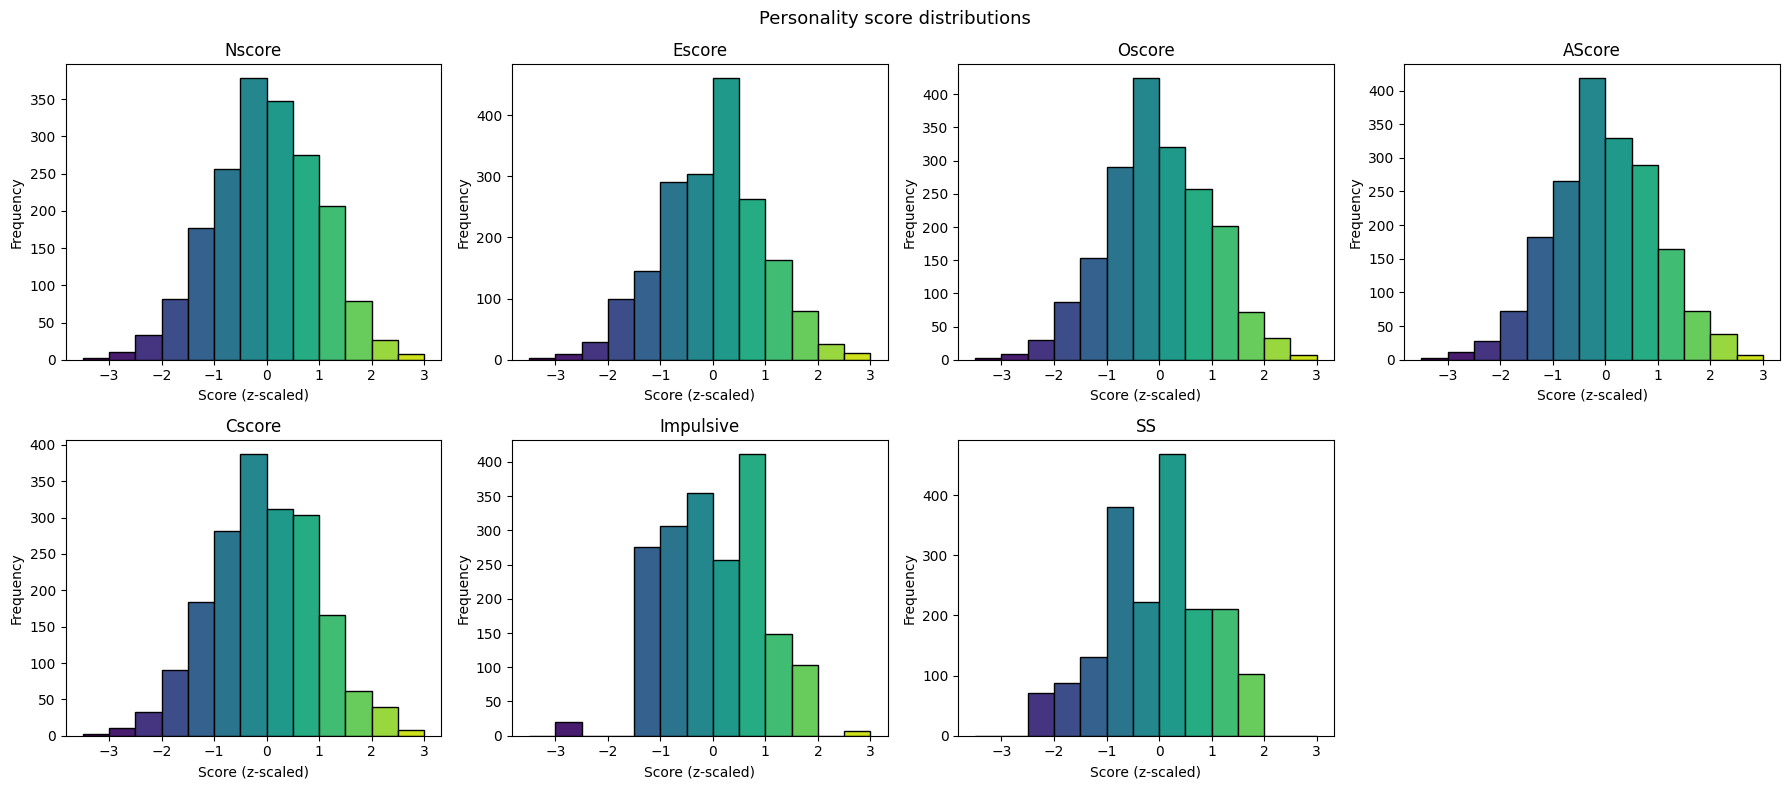

In [15]:
# Histograms for all seven personality scores in a single figure
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

myBins = np.arange(-3.5, 3.5, 0.5)     # same bin width for all scores to allow direct comparison

for i, col in enumerate(personality_scores):
    heights, bins, patches = axes[i].hist(myData[col], bins=myBins, edgecolor='black')
    for j in range(len(patches)):
        patches[j].set_facecolor(plt.cm.viridis(j / len(patches)))
    axes[i].set_title(col)
    axes[i].set_xlabel('Score (z-scaled)')
    axes[i].set_ylabel('Frequency')

axes[-1].set_visible(False)             # hide the unused 8th subplot

plt.suptitle('Personality score distributions', fontsize=13)
plt.tight_layout()

### 8.6 Bar Charts — Drug Consumption Frequency

The drug consumption columns are **ordinal** (CL0–CL6), not continuous, bar charts are prefered to represent this value. Gaps between bars reflect the categorical nature of the values.

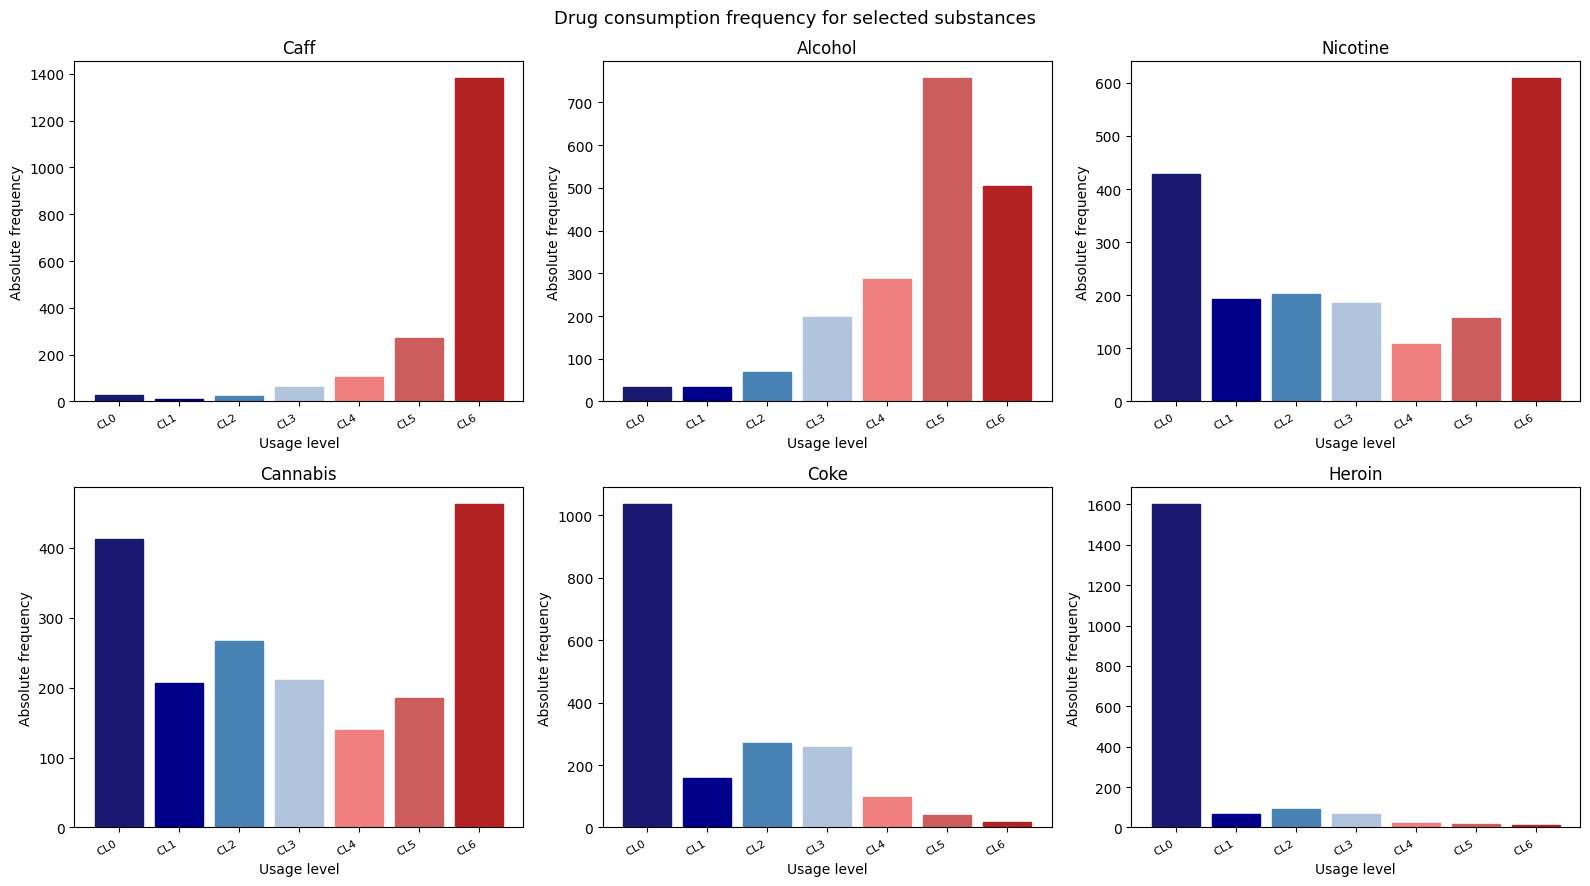

In [52]:
cl_order = ['CL0', 'CL1', 'CL2', 'CL3', 'CL4', 'CL5', 'CL6']

# Select representative substances covering the legal/illegal spectrum
selected_drugs = ['Caff', 'Alcohol', 'Nicotine', 'Cannabis', 'Coke', 'Heroin']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colormap = plt.cm.viridis
colors = ['midnightblue', 'darkblue', 'steelblue', 'lightsteelblue', 'lightcoral', 'indianred', 'firebrick']  # distinct shades for each drug

for i, drug in enumerate(selected_drugs):
    tab_drug = myData[drug].value_counts().reindex(cl_order, fill_value=0)   # reindex ensures all CL levels appear

    bars = axes[i].bar(tab_drug.index, tab_drug.values)

    for bar, color in zip(bars, colors):
        bar.set_color(color)

    axes[i].set_title(drug)
    axes[i].set_xlabel('Usage level')
    axes[i].set_ylabel('Absolute frequency')
    plt.setp(axes[i].get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Drug consumption frequency for selected substances', fontsize=13)
plt.tight_layout()

### 8.7 Grouped Boxplot — Personality Scores by Gender

A grouped boxplot allows comparison of a **continuous** feature across categories of a **qualitative** variable. The seaborn package is used here for its grouped boxplot functionality, as demonstrated in the course notebook.

Text(0.5, 0, 'Gender')

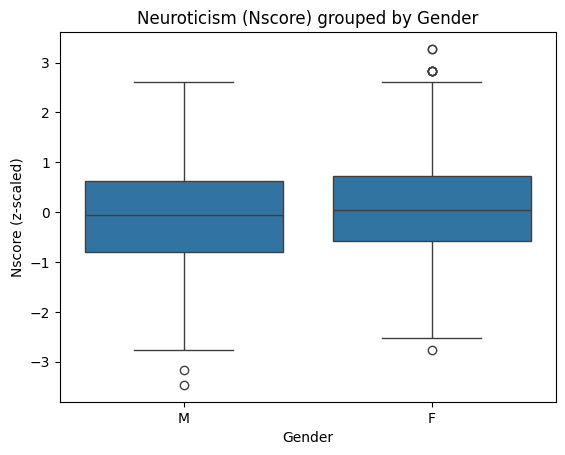

In [55]:
import seaborn as sns    # imported here where it is first needed

# Grouped boxplot: Neuroticism by Gender
fig, ax = plt.subplots()
sns.boxplot(x=myData['Gender'], y=myData['Nscore'])   # x must be qualitative, y must be continuous
ax.set_title('Neuroticism (Nscore) grouped by Gender')
ax.set_ylabel('Nscore (z-scaled)')
ax.set_xlabel('Gender')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, '18-24'),
  Text(1, 0, '25-34'),
  Text(2, 0, '35-44'),
  Text(3, 0, '45-54'),
  Text(4, 0, '55-64'),
  Text(5, 0, '65+')])

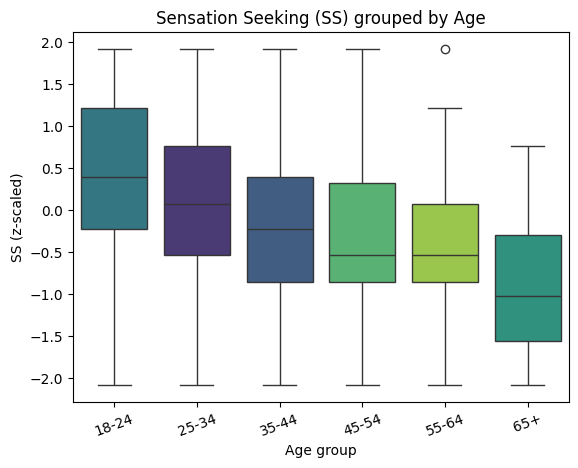

In [56]:
# Grouped boxplot: Sensation Seeking by Age group
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

ax = sns.boxplot(x=myData['Age'], y=myData['SS'],
                 order=age_order,                         # enforce the natural age ordering on the x-axis
                 hue=myData['Age'], palette='viridis', legend=False)
ax.set_title('Sensation Seeking (SS) grouped by Age')
ax.set_ylabel('SS (z-scaled)')
ax.set_xlabel('Age group')
plt.xticks(rotation=20)

### 8.8 Violin Plot — Neuroticism by Gender

The violin plot combines a boxplot with a smoothed histogram. It shows both the distributional shape and the summary statistics (median, IQR, whiskers) simultaneously.

Text(0.5, 0, 'Gender')

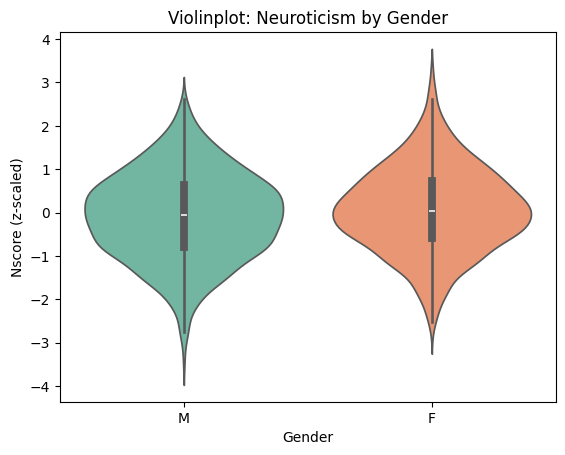

In [57]:
ax = sns.violinplot(x=myData['Gender'], y=myData['Nscore'],
                    hue=myData['Gender'], palette='Set2', legend=False)
ax.set_title('Violinplot: Neuroticism by Gender')
ax.set_ylabel('Nscore (z-scaled)')
ax.set_xlabel('Gender')

---
## 9. Measures of Location

Location measures describe where the centre of the data lies. The correct measure depends on the measurement scale: the **mean** for quantitative continuous features, the **mode** for ordinal and nominal features. The **median** is preferred over the mean when a distribution may be skewed.

### 9.1 Mean — Personality Scores

The mean is computed using `numpy`.

In [ ]:
# Mean using numpy
np_mean_Nscore = np.mean(myData['Nscore'])

print('Mean of Nscore:  %.4f' % np_mean_Nscore)

In [18]:
# Column-wise means for all personality scores (axis = 0)
numeric_data = myData[personality_scores]       # select only the quantitative personality columns
mean_values = numeric_data.mean(axis=0)

print('Column-wise means of personality scores:')
print(mean_values)

Column-wise means of personality scores:
Nscore      -0.000119
Escore       0.000143
Oscore      -0.000225
AScore       0.000242
Cscore      -0.000383
Impulsive    0.007335
SS          -0.002667
dtype: float64


### 9.2 Median — Personality Scores

In [60]:
# Median — nanmedian handles missing values if any are present
np_median_Nscore = np.nanmedian(myData['Nscore'])

print('Median of Nscore:  %.4f' % np_median_Nscore)

Median of Nscore:  0.0426


### 9.3 Quartiles, Quantiles and Percentiles

In [65]:
from tabulate import tabulate

# Quartiles using numpy and pandas — both approaches shown
np_q1_Nscore = np.nanquantile(myData['Nscore'], 0.25)      # lower quartile (numpy)
np_q3_Nscore = np.nanquantile(myData['Nscore'], 0.75)      # upper quartile (numpy)

data = [['Lower Quartile (Q1)', 'Upper Quartile (Q3)'],
        [np_q1_Nscore,   np_q3_Nscore]]


print(tabulate(data, headers='firstrow', tablefmt='grid'))

+-----------------------+-----------------------+
|   Lower Quartile (Q1) |   Upper Quartile (Q3) |
+=======================+=======================+
|              -0.67825 |               0.62967 |
+-----------------------+-----------------------+


### 9.4 Mode — Drug Consumption Features

For **ordinal** drug features, the mean is not meaningful (CL-codes are category labels, not numbers). The mode (most frequently occurring value) is the correct location measure.

In [ ]:
from statistics import mode    # imported here where it is first needed

# Mode for selected drug features — both statistics and pandas approaches shown
selected_drugs_mode = ['Caff', 'Alcohol', 'Nicotine', 'Cannabis', 'Coke', 'Heroin']

stat_mode_caff = mode(myData['Caff'])               # mode using the statistics package

print('Mode for Caff (using statistics package): %s' % stat_mode_caff)

print()

# Mode summary for all selected substances
for drug in selected_drugs_mode:
    mode_val  = mode(myData[drug])
    mode_freq = (myData[drug] == mode_val).sum()      # absolute frequency of the mode
    rel_freq  = mode_freq / len(myData) * 100          # relative frequency
    print('Mode for %-10s: %s  (abs. freq: %d, rel. freq: %.1f%%)' % (drug, mode_val, mode_freq, rel_freq))

### 9.5 Summary Table — Location Measures for Personality Scores

In [ ]:
header = ['Feature', 'Mean', 'Median', 'Q1 (25%)', 'Q3 (75%)']
rows = []

for col in personality_scores:
    s = myData[col].dropna()
    rows.append([
        col,
        '%.4f' % np.mean(s),
        '%.4f' % np.nanmedian(s),
        '%.4f' % np.nanquantile(s, 0.25),
        '%.4f' % np.nanquantile(s, 0.75)
    ])

print(tabulate(rows, headers=header, tablefmt='grid'))

### 9.6 Grouped Analysis — Mean Sensation Seeking (SS) by Age Group

Grouping data by a qualitative variable and comparing means shows whether a feature behaves differently under different conditions. In this case taking Sensation Seeking and comparing the means of the different Age Groups.

In [ ]:
# Mean Sensation Seeking per age group
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
grouped_ss = myData.groupby('Age')['SS'].mean().reindex(age_order)   # reindex to enforce ordinal age order

print('Mean Sensation Seeking (SS) by age group:')
print(grouped_ss)

print('\nHighest SS mean: age group %s (%.4f)' % (grouped_ss.idxmax(), grouped_ss.max()))
print('Lowest  SS mean: age group %s (%.4f)' % (grouped_ss.idxmin(), grouped_ss.min()))

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, '18-24'),
  Text(1, 0, '25-34'),
  Text(2, 0, '35-44'),
  Text(3, 0, '45-54'),
  Text(4, 0, '55-64'),
  Text(5, 0, '65+')])

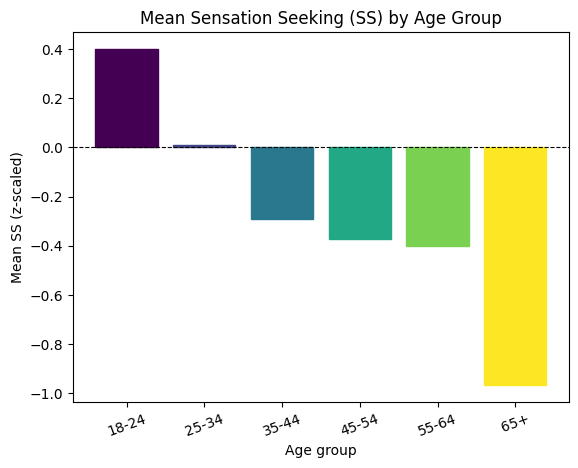

In [24]:
# Column chart of grouped means
fig, ax = plt.subplots()

bars = ax.bar(grouped_ss.index, grouped_ss.values)

colormap = plt.cm.viridis
colors = colormap(np.linspace(0, 1, len(grouped_ss)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')   # reference line at the theoretical mean of z-scores
ax.set_title('Mean Sensation Seeking (SS) by Age Group')
ax.set_xlabel('Age group')
ax.set_ylabel('Mean SS (z-scaled)')
plt.xticks(rotation=20)

---
## 10. Measures of Dispersion

Dispersion measures quantify the spread of data around the central value. A low value means data are tightly grouped; a high value means they are spread over a wide range.

### 10.1 Standard Deviation

In [ ]:
# numpy and pandas calculate deviation differently (n / n-1)
pd_std_Nscore = myData['Nscore'].std()          # empirical std (n-1)

print('Standard deviation of Nscore: %.4f' % pd_std_Nscore)

### 10.2 Interquartile Range (IQR)

In [ ]:
# IQR = Q3 - Q1; corresponds to the length of the box in a boxplot
for col in personality_scores:
    q3, q1 = np.percentile(myData[col].dropna(), [75, 25])   # compute both quartiles in one call
    iqr = q3 - q1
    print('IQR for %-10s: %.4f' % (col, iqr))

### 10.3 Range

In [27]:
# Range = max - min. Sensitive to outliers; should be used alongside the IQR.
for col in personality_scores:
    spw = max(myData[col].dropna()) - min(myData[col].dropna())
    print('Range for %-10s: %.4f' % (col, spw))

Range for Nscore    : 6.7383
Range for Escore    : 6.5479
Range for Oscore    : 6.1755
Range for AScore    : 6.9287
Range for Cscore    : 6.9287
Range for Impulsive : 5.4568
Range for SS        : 4.0002


### 10.4 Coefficient of Variation

Not important as the values are z-scored with mean near 0, causing the Coefficient Variation to be large and therefore, less informative.

In [ ]:
def varcoeff(x):
    """Function for calculating the coefficient of variation.
    Input:  column of a data frame (Series or array)
    Output: coefficient of variation in percent"""
    vc = np.std(x) / np.abs(np.mean(x)) * 100
    return vc

for col in personality_scores:
    vc = varcoeff(myData[col].dropna())
    print('Coefficient of variation for %-10s: %.1f%%' % (col, vc))

### 10.5 Complete Summary Table — Location and Dispersion

In [ ]:
header = ['Feature', 'Mean', 'Median', 'Std Dev (n-1)', 'IQR', 'Range']
rows = []

for col in personality_scores:
    s = myData[col].dropna()
    q3, q1 = np.percentile(s, [75, 25])
    rows.append([
        col,
        '%.4f' % np.mean(s),
        '%.4f' % np.nanmedian(s),
        '%.4f' % s.std(),                  
        '%.4f' % (q3 - q1),
        '%.4f' % (max(s) - min(s))
    ])

print(tabulate(rows, headers=header, tablefmt='grid'))

+-----------+---------+----------+-----------------+--------+---------+
| Feature   |    Mean |   Median |   Std Dev (n-1) |    IQR |   Range |
+===========+=========+==========+=================+========+=========+
| Nscore    | -0.0001 |   0.0426 |          0.9983 | 1.3079 |  6.7383 |
+-----------+---------+----------+-----------------+--------+---------+
| Escore    |  0.0001 |   0.0033 |          0.9976 | 1.3329 |  6.5479 |
+-----------+---------+----------+-----------------+--------+---------+
| Oscore    | -0.0002 |  -0.0193 |          0.9964 | 1.4406 |  6.1755 |
+-----------+---------+----------+-----------------+--------+---------+
| AScore    |  0.0002 |  -0.0173 |          0.9975 | 1.3673 |  6.9287 |
+-----------+---------+----------+-----------------+--------+---------+
| Cscore    | -0.0004 |  -0.0066 |          0.9978 | 1.2374 |  6.9287 |
+-----------+---------+----------+-----------------+--------+---------+
| Impulsive |  0.0073 |  -0.2171 |          0.9547 | 1.241  |  5

---
## 11. Boxplot

A boxplot provides a compact graphical summary: the median (line inside the box), IQR (box height/length), whiskers (up to 1.5×IQR from each quartile), and individual outlier points beyond the whiskers.

### 11.1 Single Boxplot

In [ ]:
fig, ax = plt.subplots()

filtered_values = myData['Nscore'].dropna()    # remove missing values before plotting

ax.boxplot(filtered_values)                    # boxplot using matplotlib
ax.set_title('Neuroticism (Nscore)')
ax.set_ylabel('Score (z-scaled)')
plt.xticks([])                                 # remove x-tick since there is only one group

In [ ]:
# Styled horizontal boxplot using the pandas method
ax = myData.boxplot(column='Nscore', vert=False, patch_artist=True)   # vert=False -> horizontal

for patch in ax.artists:                       # change colour of the box
    patch.set_facecolor('lightblue')

for line in ax.lines:                          # style the median line and outlier markers
    if line.get_linestyle() == '-':
        line.set_color('red')
        line.set_linewidth(2)
    elif line.get_marker() == 'o':
        line.set_markerfacecolor('green')
        line.set_markeredgecolor('green')
        line.set_marker('D')                   # diamond-shaped marker for outliers

ax.set_title('Neuroticism (Nscore) — horizontal boxplot')
ax.set_xlabel('Score (z-scaled)')

### 11.2 All Personality Scores Side by Side

Text(0.5, 0, 'Personality trait')

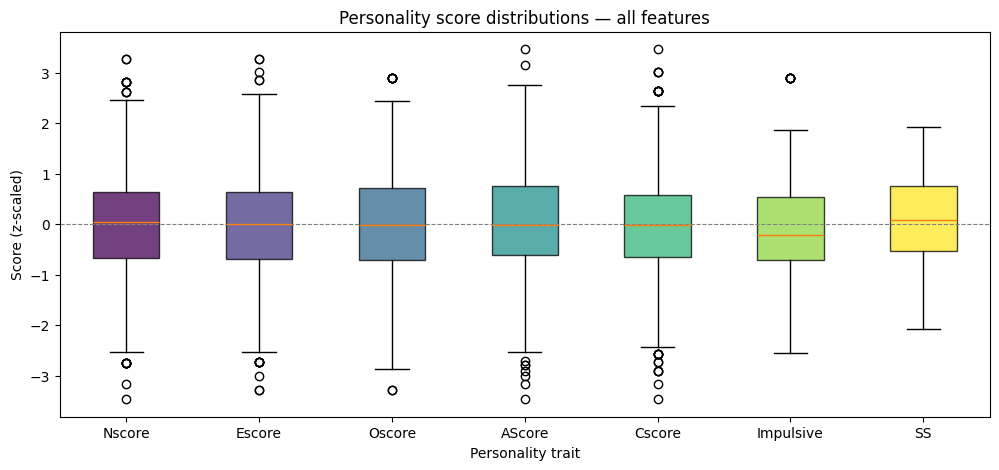

In [76]:
fig, ax = plt.subplots(figsize=(12, 5))

data_to_plot = [myData[col].dropna().values for col in personality_scores]

ax.boxplot(data_to_plot, tick_labels=personality_scores, patch_artist=True)

colormap = plt.cm.viridis
colors = colormap(np.linspace(0, 1, len(personality_scores)))
for patch, color in zip(ax.patches, colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')   # reference line at theoretical mean of z-scores
ax.set_title('Personality score distributions — all features')
ax.set_ylabel('Score (z-scaled)')
ax.set_xlabel('Personality trait')

---
## 12. Outlier Detection

Two methods are applied to detect outliers in the personality scores.

### 12.1 Standard Deviation Rule

A value is flagged as an outlier if it lies outside [x̄ − 3σ, x̄ + 3σ]. This method is based on the normal distribution: under a perfect normal distribution, fewer than 0.3% of values should fall outside this interval.

In [77]:
print('Outlier detection — 3-sigma rule [mean - 3*std, mean + 3*std]:')
print()

header = ['Feature', 'Mean', 'Std Dev', 'Lower bound', 'Upper bound', 'Outliers (n)']
rows = []

for col in personality_scores:
    s = myData[col].dropna()
    x_bar = np.mean(s)
    sigma = np.std(s)
    lower = x_bar - 3 * sigma
    upper = x_bar + 3 * sigma
    n_outliers = ((s < lower) | (s > upper)).sum()
    rows.append([col,
                 '%.4f' % x_bar,
                 '%.4f' % sigma,
                 '%.4f' % lower,
                 '%.4f' % upper,
                 n_outliers])

print(tabulate(rows, headers=header, tablefmt='grid'))

Outlier detection — 3-sigma rule [mean - 3*std, mean + 3*std]:

+-----------+---------+-----------+---------------+---------------+----------------+
| Feature   |    Mean |   Std Dev |   Lower bound |   Upper bound |   Outliers (n) |
+===========+=========+===========+===============+===============+================+
| Nscore    | -0.0001 |    0.9981 |       -2.9944 |        2.9941 |              4 |
+-----------+---------+-----------+---------------+---------------+----------------+
| Escore    |  0.0001 |    0.9974 |       -2.9919 |        2.9922 |              6 |
+-----------+---------+-----------+---------------+---------------+----------------+
| Oscore    | -0.0002 |    0.9961 |       -2.9886 |        2.9882 |              2 |
+-----------+---------+-----------+---------------+---------------+----------------+
| AScore    |  0.0002 |    0.9972 |       -2.9914 |        2.9919 |              5 |
+-----------+---------+-----------+---------------+---------------+----------------+
|

### 12.2 IQR Rule

A value is flagged as an outlier if it lies outside [Q1 − 1.5·IQR, Q3 + 1.5·IQR]. This is the same rule used to set the whisker length in boxplots. It is more robust than the σ-rule because it makes no distributional assumption.

In [78]:
print('Outlier detection — IQR rule [Q1 - 1.5*IQR, Q3 + 1.5*IQR]:')
print()

header = ['Feature', 'Q1', 'Q3', 'IQR', 'Lower bound', 'Upper bound', 'Outliers (n)', '% of data']
rows = []

for col in personality_scores:
    s = myData[col].dropna()
    q3, q1 = np.percentile(s, [75, 25])    # compute both quartiles in a single call
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    rows.append([col,
                 '%.4f' % q1,
                 '%.4f' % q3,
                 '%.4f' % iqr,
                 '%.4f' % lower,
                 '%.4f' % upper,
                 n_outliers,
                 '%.2f%%' % (n_outliers / len(s) * 100)])

print(tabulate(rows, headers=header, tablefmt='grid'))

Outlier detection — IQR rule [Q1 - 1.5*IQR, Q3 + 1.5*IQR]:

+-----------+---------+--------+--------+---------------+---------------+----------------+-------------+
| Feature   |      Q1 |     Q3 |    IQR |   Lower bound |   Upper bound |   Outliers (n) | % of data   |
+===========+=========+========+========+===============+===============+================+=============+
| Nscore    | -0.6783 | 0.6297 | 1.3079 |       -2.6401 |        2.5915 |             19 | 1.01%       |
+-----------+---------+--------+--------+---------------+---------------+----------------+-------------+
| Escore    | -0.6951 | 0.6378 | 1.3329 |       -2.6944 |        2.6371 |             14 | 0.74%       |
+-----------+---------+--------+--------+---------------+---------------+----------------+-------------+
| Oscore    | -0.7173 | 0.7233 | 1.4406 |       -2.8781 |        2.8842 |              9 | 0.48%       |
+-----------+---------+--------+--------+---------------+---------------+----------------+----------

The IQR method identifies slightly more outliers than the σ-rule in most features. Both methods detect only a small number of extreme values. Since scores originate from a validated psychometric instrument, extreme values most likely represent **genuine individual differences** rather than measurement errors. Removal is therefore not justified. As recommended in Chapter 5, Section 5.1.5, the preferred treatment is to use **robust methods** — for example, the median instead of the mean — when comparing groups that include these extreme observations.

---
## 13. Summary of Key Findings

The exploratory data analysis of the Drug Consumption dataset concludes with the following findings:

1. **No missing values** — the mandatory survey design ensured completeness across all 1,884 rows and 31 features.
2. **Sample characteristics** — nearly gender-balanced (943 male, 941 female), skewed toward younger respondents (643 in the 18–24 group), and dominated by UK participants (1,043 out of 1,884).
3. **Personality scores** are approximately normally distributed and centred near zero (mean ≈ 0, std ≈ 1), consistent with their z-score standardisation. Mean and median are nearly identical for all scores, confirming approximate symmetry.
4. **Legal substances** show far higher recent use (Caffeine mode CL6 at 73.5%; Alcohol mode CL5 at 40.2%) than illegal ones (Heroin mode CL0 at 85.1%; Cocaine mode CL0 at 55.0%).
5. **Sensation Seeking declines steadily with age** — from a mean of +0.40 in the 18–24 group to −0.97 in the 65+ group.
6. **Outliers** are few in every personality score and plausibly represent genuine extremes; no removal is justified.
7. **Semer validity check** — only 8 respondents (0.4%) claimed use of the fictitious substance, confirming general data reliability.